> **Solution version** -- this notebook contains the complete code of all exercises, executed from top to bottom, and answer elements for each observation question. The student version is available on the course webpage.


# PAC-Bayes 3 -- Bounding the risk of the majority vote

The bounds of notebook 2 control the Gibbs risk $R(G_Q)$, the average risk of the voters. But an ensemble predicts with the majority vote $B_Q$.
Here we study the relations between the two (lecture notes, Section 5): the first-order bound $R(B_Q)\leq 2R(G_Q)$, the tandem bound $R(B_Q)\leq 4e_Q$,
the C-bound and the Chebyshev-Cantelli family. We first compute their "oracle" values on a large test set, to understand what they capture, and then
their PAC-Bayesian (empirical) versions using out-of-bag samples.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

rng = np.random.RandomState(0)

class BaggedTrees:
    # A random forest written by hand, which remembers the out-of-bag samples of each tree.
    def __init__(self, n_estimators=100, max_features="sqrt", max_depth=None, bootstrap_frac=1.0, random_state=0):
        self.n_estimators, self.max_features, self.max_depth = n_estimators, max_features, max_depth
        self.bootstrap_frac, self.random_state = bootstrap_frac, random_state

    def fit(self, X, y):
        r = np.random.RandomState(self.random_state)
        m = len(y); k = int(self.bootstrap_frac * m)
        self.trees_, oob = [], []
        for t in range(self.n_estimators):
            idx = r.randint(0, m, k)
            mask = np.ones(m, bool); mask[idx] = False
            self.trees_.append(DecisionTreeClassifier(max_features=self.max_features, max_depth=self.max_depth,
                                                      random_state=r.randint(1 << 30)).fit(X[idx], y[idx]))
            oob.append(mask)
        self.oob_ = np.array(oob)
        return self

    def votes(self, X):
        return np.array([t.predict(X) for t in self.trees_])      # (n_voters, n_points), values in {-1,+1}

def mv_risk(V, y, rho):
    return np.mean(np.where(rho @ V >= 0, 1, -1) != y)


## I. Joint error and disagreement

For a posterior $\rho$ over voters, let $W_\rho(x,y)=\sum_t\rho_t\,\mathbb 1[h_t(x)\neq y]$. Then

- Gibbs risk: $R(G_\rho)=\mathbb E[W_\rho]$;
- joint error (tandem loss): $e_\rho=\mathbb E_{h,h'\sim\rho^2}\mathbb P(h(x)\neq y,\ h'(x)\neq y)=\mathbb E[W_\rho^2]$;
- disagreement: $d_\rho=\mathbb E_{h,h'\sim\rho^2}\mathbb P(h(x)\neq h'(x))=\mathbb E[2W_\rho(1-W_\rho)]$ (no label needed!).

With the matrix of errors $E_{ti}=\mathbb 1[h_t(x_i)\neq y_i]$, the matrix of pairwise joint errors is $\frac1m EE^\top$. Here is the Gibbs risk and the matrix of pairwise joint errors.


Gibbs risk 0.188, majority vote 0.079


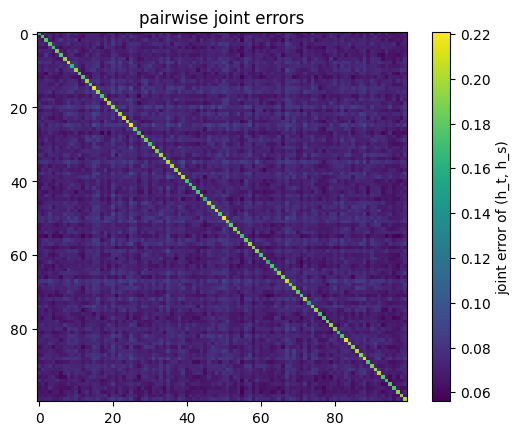

In [2]:
X, y = make_classification(4000, 20, n_informative=8, n_redundant=4, flip_y=0.05, random_state=2)
y = 2 * y - 1
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5, random_state=0)
bt = BaggedTrees(100, random_state=0).fit(Xtr, ytr)
V = bt.votes(Xte)
rho = np.ones(100) / 100

E = (V != yte).astype(float)
gibbs = rho @ E.mean(1)
L_pair = E @ E.T / E.shape[1]            # joint error of each pair of trees
print(f"Gibbs risk {gibbs:.3f}, majority vote {mv_risk(V, yte, rho):.3f}")
plt.imshow(L_pair, cmap="viridis"); plt.colorbar(label="joint error of (h_t, h_s)"); plt.title("pairwise joint errors"); plt.show()


### Exercise 1

Write a function `second_order(V, y, rho)` returning $e_\rho$ (through the pairwise matrix: $\rho^\top L\rho$) and $d_\rho$ (through the pairwise disagreement matrix, **without using the labels**).
Check with `np.testing.assert_allclose` that (i) $e_\rho=\mathbb E[W_\rho^2]$, (ii) $R(G_\rho)=e_\rho+d_\rho/2$, for the uniform posterior and for a random Dirichlet posterior.


In [3]:
def second_order(V, y, rho):
    E = (V != y).astype(float)
    L = E @ E.T / E.shape[1]
    D = np.mean(V[:, None, :] != V[None, :, :], axis=2)       # pairwise disagreement, labels not used
    return rho @ L @ rho, rho @ D @ rho

for r in [np.ones(100) / 100, rng.dirichlet(np.ones(100))]:
    e, d = second_order(V, yte, r)
    W = r @ (V != yte)
    np.testing.assert_allclose(e, np.mean(W**2))
    np.testing.assert_allclose(r @ (V != yte).mean(1), e + d / 2)
    print(f"e = {e:.4f}, d = {d:.4f}, Gibbs = {e + d / 2:.4f}")

e = 0.0733, d = 0.2299, Gibbs = 0.1883
e = 0.0751, d = 0.2286, Gibbs = 0.1894



## II. Oracle bounds and diversity

The three bounds on $R(B_\rho)=\mathbb P(W_\rho\geq 1/2)$:
$$\text{FO: } 2R(G_\rho),\qquad \text{TND: } 4e_\rho,\qquad \text{C-bound: } 1-\frac{(1-2R(G_\rho))^2}{1-2d_\rho}\ \ (\text{if } R(G_\rho)<1/2).$$
Let us compute them on the test set (this is why we call them *oracle*: they use the true distribution, approximated by a large test set) for forests of increasing diversity.


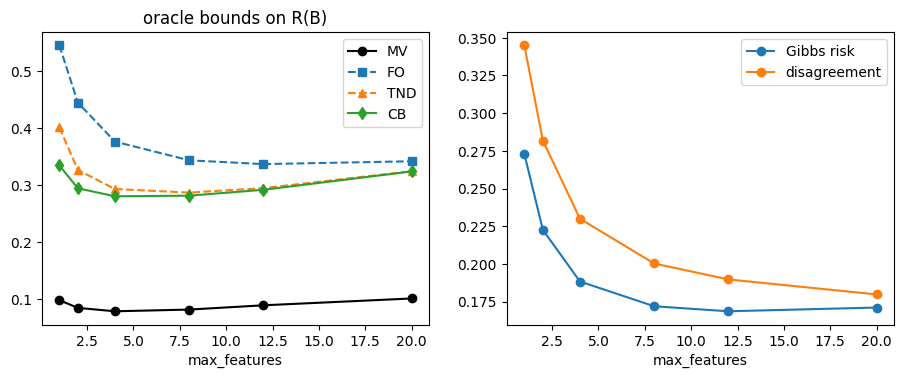

In [4]:
def oracle_bounds(V, y, rho):
    E = (V != y).astype(float)
    g = rho @ E.mean(1)
    e = rho @ (E @ E.T / E.shape[1]) @ rho
    d = 2 * (g - e)
    cb = 1 - (1 - 2 * g)**2 / (1 - 2 * d) if g < 0.5 else 1.0
    return dict(MV=mv_risk(V, y, rho), FO=2 * g, TND=4 * e, CB=cb, gibbs=g, dis=d)

feats = [1, 2, 4, 8, 12, 20]
rows = [oracle_bounds(BaggedTrees(100, max_features=f, random_state=0).fit(Xtr, ytr).votes(Xte), yte, rho) for f in feats]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for k, st in [("MV", "ko-"), ("FO", "s--"), ("TND", "^--"), ("CB", "d-")]:
    axes[0].plot(feats, [r[k] for r in rows], st, label=k)
axes[0].set_xlabel("max_features"); axes[0].legend(); axes[0].set_title("oracle bounds on R(B)")
axes[1].plot(feats, [r["gibbs"] for r in rows], "o-", label="Gibbs risk")
axes[1].plot(feats, [r["dis"] for r in rows], "o-", label="disagreement")
axes[1].set_xlabel("max_features"); axes[1].legend(); plt.show()

$$ $$

**Question 1:** Which bound is the closest to the true risk of the vote? When is the tandem bound better than the first-order bound (compare the disagreement with the Gibbs risk)? What does the right panel say about the strength/diversity trade-off?

$$ $$

*Answer elements.* The C-bound is the tightest, then the tandem bound, the first-order bound being the loosest; all of them remain well above the risk of the vote (they are Markov/Chebyshev-type inequalities, which cannot exploit the full shape of the distribution of $W_\rho$). Since $4e=2R(G)-2(d-R(G))$, the tandem bound beats the first-order bound exactly when $d_\rho\geq R(G_\rho)$: this holds for all the forests here, but the gap shrinks as `max_features` grows. When `max_features` increases the trees become stronger (smaller Gibbs risk) but more similar (smaller disagreement): the C-bound, which combines both effects, is minimal for an intermediate value, like the risk of the vote itself.


A classical toy model to understand diversity is the **Condorcet jury**: $n$ voters that err independently with probability $p$. Here is the risk of the vote as a function of $n$ for $p=0.3$.


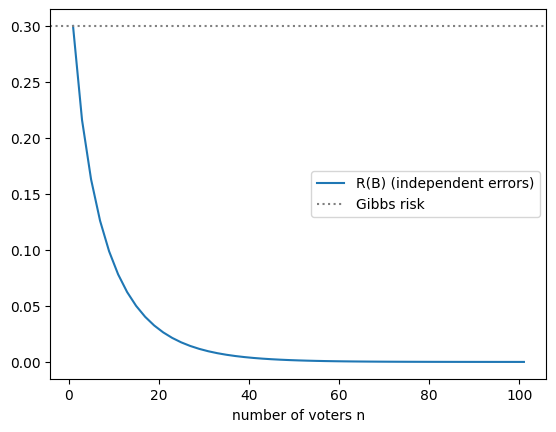

In [5]:
from scipy.stats import binom
p = 0.3
ns = np.arange(1, 102, 2)
plt.plot(ns, [binom.sf(n // 2, n, p) for n in ns], label="R(B) (independent errors)")
plt.axhline(p, color="grey", ls=":", label="Gibbs risk")
plt.xlabel("number of voters n"); plt.legend(); plt.show()


### Exercise 2

Simulate $n=25$ voters with individual error $p=0.3$ whose errors are **correlated**: with probability $c$ all voters copy the error pattern of a single "leader" voter,
otherwise they err independently. For $c\in\{0,0.25,0.5,0.75,1\}$ and $20000$ simulated points, compute the risk of the uniform vote, the Gibbs risk, the disagreement and the three oracle bounds. Comment.


In [6]:
n, p, N = 25, 0.3, 20000
for c in [0, 0.25, 0.5, 0.75, 1]:
    leader = rng.rand(N) < p
    indep = rng.rand(n, N) < p
    copy = rng.rand(N) < c
    Err = np.where(copy[None, :], leader[None, :], indep).astype(float)   # (n, N) error indicators
    W = Err.mean(0)
    g, e = W.mean(), np.mean(W**2); d = 2 * (g - e)
    mv = np.mean(W >= 0.5)
    cb = 1 - (1 - 2 * g)**2 / (1 - 2 * d)
    print(f"c={c:.2f}  MV={mv:.3f}  Gibbs={g:.3f}  dis={d:.3f}  FO={2*g:.3f}  TND={4*e:.3f}  CB={cb:.3f}")

c=0.00  MV=0.018  Gibbs=0.300  dis=0.403  FO=0.600  TND=0.394  CB=0.174
c=0.25  MV=0.090  Gibbs=0.302  dis=0.303  FO=0.604  TND=0.602  CB=0.602
c=0.50  MV=0.157  Gibbs=0.299  dis=0.203  FO=0.598  TND=0.789  CB=0.727
c=0.75  MV=0.231  Gibbs=0.301  dis=0.100  FO=0.603  TND=1.006  CB=0.803
c=1.00  MV=0.300  Gibbs=0.300  dis=0.000  FO=0.600  TND=1.200  CB=0.840


*Answer elements.* With $c=0$ the vote is much better than the voters (about $2\%$ vs $30\%$), the disagreement is close to its maximum $2p(1-p)=0.42$ and the C-bound ($0.17$) is much smaller than the first-order bound ($0.6$). As $c$ grows the disagreement decreases and the vote gets closer to the Gibbs classifier; the second-order bounds degrade quickly and even become worse than the first-order bound (tandem $>0.6$ as soon as $d<R(G)$). With $c=1$ all the voters are identical: $d=0$ and $R(B)=R(G)$; the tandem bound is then $4R(G)$, twice the first-order one.


## III. The Chebyshev-Cantelli family

For any $\mu<1/2$: $R(B_\rho)\leq \dfrac{e_\rho-2\mu R(G_\rho)+\mu^2}{(1/2-\mu)^2}$ (Wu et al., 2021). For $\mu=0$ this is the tandem bound. Let us plot this family for one of the forests above.


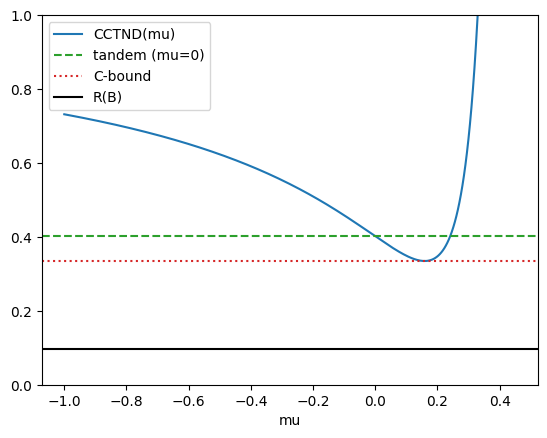

In [7]:
st = rows[0]
g, e = st["gibbs"], (st["TND"] / 4)
mus = np.linspace(-1, 0.45, 300)
vals = (e - 2 * mus * g + mus**2) / (0.5 - mus)**2
plt.plot(mus, vals, label="CCTND(mu)")
plt.axhline(st["TND"], color="C2", ls="--", label="tandem (mu=0)")
plt.axhline(st["CB"], color="C3", ls=":", label="C-bound")
plt.axhline(st["MV"], color="k", label="R(B)")
plt.ylim(0, 1); plt.xlabel("mu"); plt.legend(); plt.show()

$$ $$

**Question 2:** What is the minimum of the curve? Can you guess the optimal $\mu$ from the expression? (Hint: the answer is in Exercise 5 of the TD.)

$$ $$

*Answer elements.* The minimum coincides with the C-bound. Setting the derivative to zero gives $\mu^\star=\frac{R(G)/2-e}{1/2-R(G)}$ (which is negative when $e>R(G)/2$), and plugging it in gives $\frac{\mathrm{Var}(W)}{\mathrm{Var}(W)+(1/2-\mathbb E W)^2}$, which is exactly Cantelli's inequality, i.e. the C-bound.


### Exercise 3

Find the minimizer $\mu^\star$ of the family numerically (e.g. `scipy.optimize.minimize_scalar` on $(-10, 0.5)$) for the six forests of part II, and check with an `assert`
that the minimal value is equal to the C-bound (relative tolerance $10^{-4}$) and that $\mu^\star$ matches the closed form $\frac{R(G)/2-e}{1/2-R(G)}$.


In [8]:
from scipy.optimize import minimize_scalar
# Model: numerical minimization of a one-dimensional function on an interval
res = minimize_scalar(lambda t: (t - 0.3)**2 + 1, bounds=(-10, 0.5), method="bounded")
print(res.x, res.fun)

0.3000000000000004 1.0


In [9]:
for f, st in zip(feats, rows):
    g, e = st["gibbs"], st["TND"] / 4
    obj = lambda t: (e - 2 * t * g + t**2) / (0.5 - t)**2
    r = minimize_scalar(obj, bounds=(-10, 0.4999), method="bounded", options={"xatol": 1e-10})
    mu_closed = (g / 2 - e) / (0.5 - g)
    np.testing.assert_allclose(r.fun, st["CB"], rtol=1e-4)
    np.testing.assert_allclose(r.x, mu_closed, atol=1e-3)
    print(f"max_features={f:2d}: mu* = {r.x:.4f} (closed form {mu_closed:.4f}), min = {r.fun:.4f} = C-bound {st['CB']:.4f}")

max_features= 1: mu* = 0.1587 (closed form 0.1587), min = 0.3347 = C-bound 0.3347
max_features= 2: mu* = 0.1067 (closed form 0.1067), min = 0.2946 = C-bound 0.2946
max_features= 4: mu* = 0.0668 (closed form 0.0668), min = 0.2805 = C-bound 0.2805
max_features= 8: mu* = 0.0433 (closed form 0.0433), min = 0.2816 = C-bound 0.2816
max_features=12: mu* = 0.0319 (closed form 0.0319), min = 0.2920 = C-bound 0.2920
max_features=20: mu* = 0.0132 (closed form 0.0132), min = 0.3242 = C-bound 0.3242



## IV. PAC-Bayesian versions with out-of-bag samples

On real problems we have no test set to compute oracle values. The out-of-bag (OOB) samples provide, for each tree, examples that were not used to build it:
the OOB losses play the role of empirical risks in the PAC-Bayesian bounds (lecture notes, Theorem 7.1), with $n_0$ the size of the smallest OOB set
(for pairs: the smallest intersection of two OOB sets). With the uniform prior $\pi$:
$$R(B_\rho)\leq 2\,\overline{\mathrm{kl}}^{-1}\Big(\rho^\top\hat L,\tfrac{\mathrm{KL}(\rho\|\pi)+\ln\frac{2\sqrt{n_0}}{\delta}}{n_0}\Big),\qquad
R(B_\rho)\leq 4\,\overline{\mathrm{kl}}^{-1}\Big(\rho^\top\hat{\mathbf L}\rho,\tfrac{2\mathrm{KL}(\rho\|\pi)+\ln\frac{2\sqrt{n_0'}}{\delta}}{n_0'}\Big).$$


In [10]:
def kl_bin(q, p):
    p = min(max(p, 1e-12), 1 - 1e-12)
    t1 = q * np.log(q / p) if q > 0 else 0.0
    t2 = (1 - q) * np.log((1 - q) / (1 - p)) if q < 1 else 0.0
    return t1 + t2

def kl_inv_upper(q, eps, tol=1e-9):
    lo, hi = q, 1.0
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if kl_bin(q, mid) > eps: hi = mid
        else: lo = mid
    return hi

def kl_div(q, p):
    mask = q > 0
    return np.sum(q[mask] * np.log(q[mask] / p[mask]))

def oob_stats(bt, X, y):
    V = bt.votes(X); O = bt.oob_.astype(float)
    Eo = (V != y) * O                                     # errors on OOB points only
    L = Eo.sum(1) / O.sum(1); n0 = int(O.sum(1).min())
    both = O @ O.T
    Lt = (Eo @ Eo.T) / np.maximum(both, 1); n0p = int(both.min())
    return L, n0, Lt, n0p

def fo_bound(rho, pi, L, n0, delta=0.05):
    return min(1, 2 * kl_inv_upper(rho @ L, (kl_div(rho, pi) + np.log(2 * np.sqrt(n0) / delta)) / n0))

def tnd_bound(rho, pi, Lt, n0p, delta=0.05):
    return min(1, 4 * kl_inv_upper(rho @ Lt @ rho, (2 * kl_div(rho, pi) + np.log(2 * np.sqrt(n0p) / delta)) / n0p))

bt = BaggedTrees(100, random_state=0).fit(Xtr, ytr)
L, n0, Lt, n0p = oob_stats(bt, Xtr, ytr)
pi = np.ones(100) / 100
print(f"m = {len(ytr)}, n0 = {n0}, n0' = {n0p}")
print(f"test risk of the vote {mv_risk(bt.votes(Xte), yte, pi):.3f} | FO bound {fo_bound(pi, pi, L, n0):.3f} | TND bound {tnd_bound(pi, pi, Lt, n0p):.3f}")

m = 2000, n0 = 698, n0' = 229
test risk of the vote 0.079 | FO bound 0.498 | TND bound 0.591


$$ $$

**Question 3:** Why is $n_0'$ much smaller than $n_0$? Which proportions of the sample do you expect for bootstrap samples of size $m$?

$$ $$

*Answer elements.* A point is out-of-bag for a tree with probability $(1-1/m)^m\approx e^{-1}\approx 0.37$, and out-of-bag for two trees with probability $\approx e^{-2}\approx 0.14$: the tandem losses are estimated on fewer examples, and the minimum over all the pairs is even smaller. This is the price of second-order information.


### Exercise 4

Study the effect of the bootstrap size on the certificates: for `bootstrap_frac` in $\{1, 0.75, 0.5, 0.3\}$, report $n_0$, $n_0'$, the test risk of the uniform vote, the FO and the TND bounds,
on this simulated dataset and on `load_digits` (classes $<5$ vs $\geq 5$, 60% for training). Which value would you recommend?


In [11]:
# Model: the same study for the number of trees
for n_est in [20, 50, 100]:
    b = BaggedTrees(n_est, random_state=0).fit(Xtr, ytr)
    L_, n0_, Lt_, n0p_ = oob_stats(b, Xtr, ytr); p_ = np.ones(n_est) / n_est
    print(f"{n_est:3d} trees: n0={n0_}, n0'={n0p_}, MV={mv_risk(b.votes(Xte), yte, p_):.3f}, "
          f"FO={fo_bound(p_, p_, L_, n0_):.3f}, TND={tnd_bound(p_, p_, Lt_, n0p_):.3f}")

 20 trees: n0=705, n0'=236, MV=0.086, FO=0.499, TND=0.613


 50 trees: n0=698, n0'=234, MV=0.084, FO=0.500, TND=0.595


100 trees: n0=698, n0'=229, MV=0.079, FO=0.498, TND=0.591


In [12]:
Xd, yd = load_digits(return_X_y=True); yd = np.where(yd >= 5, 1, -1)
Xdtr, Xdte, ydtr, ydte = train_test_split(Xd, yd, train_size=0.6, random_state=0)
for name, (A, b_, At, bt_) in {"simulated": (Xtr, ytr, Xte, yte), "digits": (Xdtr, ydtr, Xdte, ydte)}.items():
    print(name)
    for frac in [1, 0.75, 0.5, 0.3]:
        f = BaggedTrees(100, bootstrap_frac=frac, random_state=0).fit(A, b_)
        L_, n0_, Lt_, n0p_ = oob_stats(f, A, b_); p_ = np.ones(100) / 100
        print(f"  frac={frac:4.2f}: n0={n0_:4d} n0'={n0p_:4d} MV={mv_risk(f.votes(At), bt_, p_):.3f} "
              f"FO={fo_bound(p_, p_, L_, n0_):.3f} TND={tnd_bound(p_, p_, Lt_, n0p_):.3f}")

simulated


  frac=1.00: n0= 698 n0'= 229 MV=0.079 FO=0.498 TND=0.591


  frac=0.75: n0= 917 n0'= 399 MV=0.085 FO=0.490 TND=0.507


  frac=0.50: n0=1192 n0'= 689 MV=0.088 FO=0.498 TND=0.471


  frac=0.30: n0=1468 n0'=1055 MV=0.087 FO=0.524 TND=0.461
digits


  frac=1.00: n0= 358 n0'= 113 MV=0.039 FO=0.477 TND=0.565


  frac=0.75: n0= 483 n0'= 204 MV=0.043 FO=0.457 TND=0.444


  frac=0.50: n0= 639 n0'= 365 MV=0.046 FO=0.486 TND=0.407


  frac=0.30: n0= 784 n0'= 563 MV=0.057 FO=0.526 TND=0.413


*Answer elements.* Smaller bootstrap samples increase $n_0$ and above all $n_0'$, so the certificates (especially the tandem one) get tighter, while the trees get a bit weaker and the test risk of the vote increases slightly. A bootstrap size around $m/2$ is a good compromise: the vote is almost as good and the tandem bound becomes much tighter.


## Conclusion

The risk of the vote is a tail probability of $W_\rho$; the first-order bound only uses its mean, while the tandem bound and the C-bound use its second moment,
i.e. the *correlation of the errors*. They are the right tools to certify diverse ensembles. In notebook 4 we will use these bounds as learning objectives to choose the weights $\rho$.
